In [341]:
%matplotlib inline
import torch
import numpy as np
from torch.utils import data
from matplotlib_inline import backend_inline

In [342]:
# 使用 w = [2, -3.4], b = 4.2 和噪声eps噪声项生成数据
# eps 服从均值为0的正态分布

def synthetic_data(w, b, num_example):
    """生成y = xw + b + noise"""
    X = torch.normal(0, 1, (num_example, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

In [343]:
true_w = torch.tensor([2, -3.4])
true_b = torch.tensor(4.2)
true_w, true_b

(tensor([ 2.0000, -3.4000]), tensor(4.2000))

In [344]:
# 生成数据集
features, labels = synthetic_data(true_w, true_b, 1000)
print(features, labels, sep='\n')

tensor([[ 0.5665, -1.6352],
        [ 1.0491, -0.4681],
        [ 0.4937, -0.0031],
        ...,
        [-0.2407,  0.0769],
        [ 0.7352, -1.2918],
        [-0.2555, -0.3869]])
tensor([[ 1.0913e+01],
        [ 7.8887e+00],
        [ 5.1852e+00],
        [ 1.0389e+01],
        [ 7.0336e+00],
        [ 2.4463e+00],
        [-1.2612e-01],
        [-2.3504e+00],
        [ 7.5033e+00],
        [ 1.2828e+01],
        [ 5.8742e+00],
        [ 8.3078e+00],
        [ 5.4928e+00],
        [ 5.2842e+00],
        [ 3.7672e+00],
        [ 4.6110e+00],
        [ 3.1994e+00],
        [ 3.6039e+00],
        [ 7.0824e+00],
        [ 1.0209e+01],
        [ 1.4108e+01],
        [ 9.0250e+00],
        [ 1.1118e+00],
        [ 1.0206e+00],
        [ 9.7224e+00],
        [ 4.5729e+00],
        [ 5.6956e+00],
        [ 3.6581e+00],
        [ 7.1999e+00],
        [ 7.7071e+00],
        [-3.8301e+00],
        [ 2.3346e+00],
        [ 6.6406e+00],
        [ 1.5199e+00],
        [ 6.2285e+00],
        [ 5.5

In [345]:
# 读取数据集
def load_array(data_arrays, batch_size, is_train=True):
    """构造一个pytorh数据迭代器"""
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

In [346]:
batch_size = 10
data_iter = load_array((features, labels), batch_size, is_train=True)
data_iter

In [347]:
# 定义模型
from torch import nn
net = nn.Sequential(nn.Linear(2, 1))
print(net[0].weight.data, net[0].bias.data)
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)
print(net[0].weight.data, net[0].bias.data)
net.parameters() # 返回一个generator，依次返回模型参数
print()
for i in net.parameters():
    print(i,end='\n\n')

tensor([[ 0.3865, -0.2543]]) tensor([-0.5843])
tensor([[0.0091, 0.0029]]) tensor([0.])

Parameter containing:
tensor([[0.0091, 0.0029]], requires_grad=True)

Parameter containing:
tensor([0.], requires_grad=True)



In [348]:
# 定义损失函数
loss = nn.MSELoss()

In [349]:
# 定义优化算法
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

In [350]:
# 训练
num_epochs = 10
l_list = []
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)
        l_list.append(l.detach().mean())
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(X), y)
    print(f"epoch {epoch + 1}, loss {l}")

epoch 1, loss 0.00022980562062002718
epoch 2, loss 8.981801511254162e-05
epoch 3, loss 0.00011578753765206784
epoch 4, loss 8.433593029621989e-05
epoch 5, loss 6.842316361144185e-05
epoch 6, loss 4.20335381932091e-05
epoch 7, loss 0.0001160324172815308
epoch 8, loss 0.00020999838307034224
epoch 9, loss 4.6149078116286546e-05
epoch 10, loss 5.738436448154971e-05


tensor(1.4351e-05)


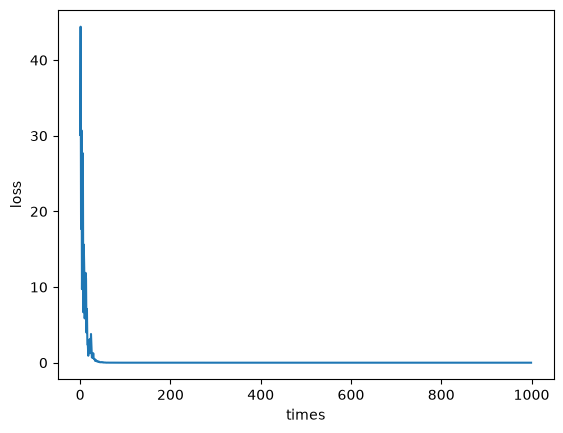

In [351]:
# 画图
import matplotlib.pyplot as plt
times = [i for i in range(0, len(l_list))]
print(min(l_list))
fig, ax = plt.subplots()
ax.set_xlabel("times")
ax.set_ylabel("loss")
ax.grid
ax.plot(times, l_list)
plt.show()

In [352]:
w = net[0].weight.data
print("w的估计误差", true_w - w.reshape(true_w.shape))
b = net[0].bias.data
print("b的估计误差", true_b - b.reshape(true_b.shape))

w的估计误差 tensor([0.0007, 0.0005])
b的估计误差 tensor(0.0003)
